# Lecture 22 - Performance Measures for Classification Tasks

# Performance Measures for Classification Tasks

Classification accuracy and e the number of correct predictions made as a ratio of all predictions made.

* **Classification accuracy** is defined as the number of correctly classified samples divided by all samples:

\begin{align*}
\text{accuracy} = \frac{N_{\text{corr}}}{N}
\end{align*}

where $N_{\text{corr}}$ is the number of correct classified samples and $N$ is the total number of samples.

* **Classification error** is defined as the number of incorrectly classified samples divided by all samples:

\begin{align*}
\text{error} = \frac{N_{\text{miss}}}{N}
\end{align*}

where $N_{\text{miss}}$ is the number of misclassified samples and $N$ is the total number of samples.

* Classification accuracy is the most common evaluation metric for classification problems, it is also the most misused. It is really only suitable when there are an equal number of observations in each class (which is rarely the case) and that all predictions and prediction errors are equally important, which is often not the case.

## Example 1: Fish Dataset

Suppose there is a 3-class classification problem, in which we would like to classify each training sample (a fish) to one of the three classes (A = salmon or B = sea bass or C = cod).

Let's assume there are 150 samples, including 30 salmon, 40 sea bass and 80 cod. Suppose our model misclassifies 4 salmon, 2 sea bass and 5 cod.

* The classification accuracy (ACC) of our binary classification model is calculated as:

\begin{align*}
\text{ACC} = \frac{26 + 38 + 75}{30 + 40 + 80} = \frac{139}{150} \approx 92.7 \%
\end{align*}

* The prediction error is calculated as:

\begin{align*}
\text{error} = \frac{4 + 2 + 5}{30+40+80} = \frac{11}{150} \approx 7.3 \%
\end{align*}

* The classification accuracy doesn't really gives an insight on which class is being misclassified the most.

## Confusion Matrix

A confusion matrix summarizes the classification accuracy across several classes. It shows the ways in which the classification model is confused when it makes predictions, allowing visualization of the performance of our algorithm. 

Generally, each row represents the instances of a actual class while each column represents the instances in an predicted class.

If the classifier is trained to distinguish between salmon, sea bass and cod. We can summarize the prediction result in the confusion matrix as follows:

|actual/predict|    salmon    |    sea bass  |      cod     |
|--------------|--------------|--------------|--------------|
|    salmon    |      26      |       2      |       2      |
|    sea bass  |       2      |       38     |       0      |
|      cod     |       2      |       3      |       75     |


In this confusion matrix, of the 30 salmons (row 1), the classifier predicted that 26 are labeled salmon correctly, 2 are wrongly labeled as sea bass, and another 2 are wrongly labeled as cod. 

All correct predictions are located in the diagonal of the table. So it is easy to visually inspect the table for prediction errors, as they will be represented by values outside the diagonal.

## Precision, Recall & Fall-Out

We are often looking to discriminate between observations with a specific binary outcome, for example, event or no event. In our example, the fish company would like to produce salmon can but the harvest contains all three species. In this way,
we can assign the event (salmon) as "positive" and no-event (not salmon) as "negative".

The confusion matrix for this two-class classification problem is:

|actual/predict|    salmon    |  non-salmon  |
|--------------|--------------|--------------|
|    salmon    |      26      |       4      |
|  non-salmon  |       4      |      116     |

* **True positive (TP):** correctly predicting positive events
* **False positive (FP):** incorrectly calling positive to a negative event
* **True negative (TN):** correctly predicting negative events
* **False negative (FN):** incorrectly labeling negative to a positive event

*In this salmon/non-salmon classification problem, what are the TP, FP, TN, FN values?*

|actual/predict|   Positive   |   Negative   |
|--------------|--------------|--------------|
|   Positive   |      TP      |      FN      |
|   Negative   |      FP      |      TN      |

* **Precision**, also called Positive Predictive Value (PPV), is the performance of detection

\begin{align*}
\text{Precision} = \text{PPV} = \frac{TP}{TP + FP}
\end{align*}

* **Recall**, also called True Positive Rate (TPR) or Sensitivity, is the probability of detection

\begin{align*}
\text{Recall} = \text{TPR} = \text{Sensitivity} = \frac{TP}{TP + FN}
\end{align*}

* **Fall-out**, also called False Positive Rate (FPR), is the probability of false alarm

\begin{align*}
\text{Fall-out} = \text{FPR} = \frac{FP}{FP + TN}
\end{align*}

* **Specificity**, also called True Negative Rate (TNR), is the probability of negative events detection

\begin{align*}
\text{Specificity} = \frac{TN}{TN + FP}
\end{align*}

* **F1-score**, also called F-score or F-measure, is a measure of a model's accuracy. It considers both the precision and the recall.

\begin{align*}
\text{F1-score} = 2\times\frac{\text{Precision}\times \text{Recall}}{\text{Precision} + \text{Recall}}
\end{align*}

* Learn about many other measures on this [Wikipedia page](https://en.wikipedia.org/wiki/Sensitivity_and_specificity) and [Scikit-Learn's Classification Metrics Module](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics).

## ROC Curves

**Receiver Operating Characteristic (ROC) curve** is the plot between the true positive rate (TPR) and the false positive rate (FPR), where the TPR is defined as the y-axis and FPR is defined as the x-axis.

* ROC curves were first developed for RADAR systems, hence the name.

* Given a binary classifier and its threshold, the (x,y) coordinates of ROC space can be calculated from all the prediction result. You trace out a ROC curve by varying the threshold to get all of the points on the ROC.

* The diagonal between (0,0) and (1,1) separates the ROC space into two areas, which are left up area and right bottom area. The points above the diagonal represent good classification (better than random guess) which below the diagonal represent bad classification (worse than random guess).

* *What is the perfect prediction point in a ROC curve?*

### Area Under the Curve (AUC)

**Area Under Curve (AUC)** is a common measure of how good a test is. It is simply the area under the ROC curve. Random guessing can achieve the diagonal line, so the minimum AUC is 1/2. The maximum AUC is 1, which is achieved by a test that is always right; the ROC curve is along the left and top axes.

For the example above, and letting $C_1$ be the negative class, and $C_2$ the positive class, we find TPR and FPR as a function of the threshold $\gamma$:

\begin{align*}
\text{TPR} &= \int_{\gamma}^{+\infty} P(x|C_2)dx = Q\left(\frac{\gamma-\mu_2}{\sigma_2}\right)\\
\text{FPR} &= \int_{\gamma}^{+\infty} P(x|C_1)dx = Q\left(\frac{\gamma-\mu_1}{\sigma_1}\right)
\end{align*}

where the $Q(x)$ function is the survival function, $Q(x) = P(X>x)$, of the random variable $X$ with a Normal density (Gaussian with mean 0 and variance 1).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('bmh')
import scipy.stats as stats

In [2]:
def Q(x):
    return stats.norm.sf(x)

In [3]:
G1 = stats.norm(loc=0, scale=np.sqrt(2))
mu1, v1 = G1.stats('mv')

G2 = stats.norm(loc=4, scale=np.sqrt(3))
mu2, v2 = G2.stats('mv')

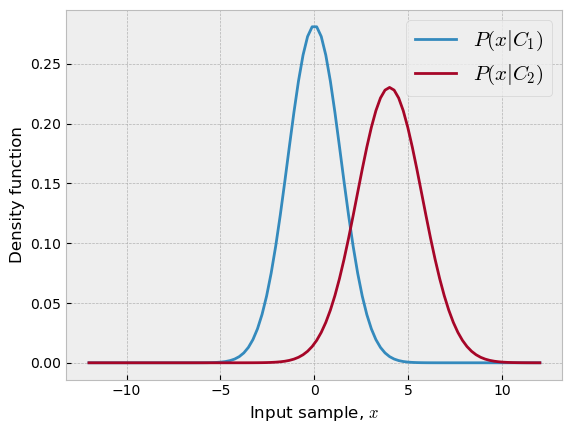

In [4]:
x = np.linspace(-12,12,100)
plt.plot(x, G1.pdf(x),label='$P(x|C_1)$')
plt.plot(x, G2.pdf(x),label='$P(x|C_2)$')
plt.legend(fontsize=15)
plt.xlabel('Input sample, $x$'); plt.ylabel('Density function');

0.9628985750756732


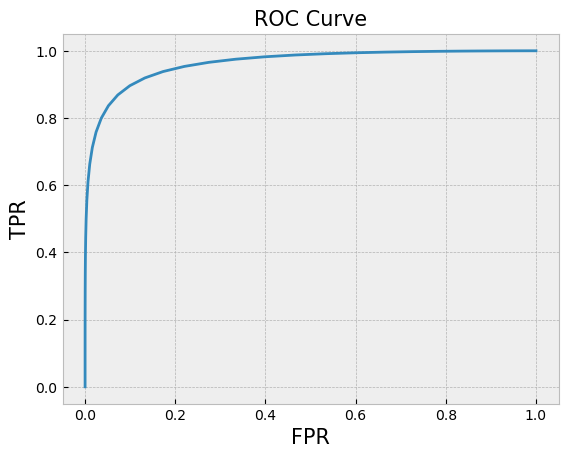

In [5]:
# threshold values (each produce a FPR-TPR pair)
gamma = np.linspace(-12,12,100)

# FPR and TPR
FPR = Q((gamma-mu1)/np.sqrt(v1))
TPR = Q((gamma-mu2)/np.sqrt(v2))

# ROC curves
plt.plot(FPR, TPR)
plt.title('ROC Curve', size=15)
plt.xlabel('FPR', size=15); plt.ylabel('TPR', size=15);

# AUC
print(np.trapz(np.flip(TPR),x=np.flip(FPR)))

Note that **KNN** is nonparametric, thus it does not model the data likelihood with a probabilistic model. But we can still plot its ROC curve.

Consider the example:

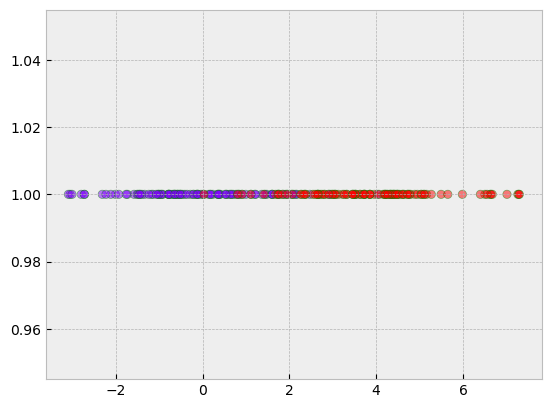

In [7]:
x = np.hstack((G1.rvs(100), G2.rvs(100))).reshape(-1,1)
t = np.hstack((np.ones(100), 2*np.ones(100)))

plt.scatter(x, np.ones(len(x)), c=t, cmap='rainbow',alpha=0.5, edgecolors='g', label='Training dataset');

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

pipe = Pipeline([('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=10, weights='uniform'))])
pipe.fit(x,t)

Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(n_neighbors=10))])

In [9]:
# Making predictions

prediction = pipe.predict(x)

In [10]:
# Accuracy Score
from sklearn.metrics import accuracy_score

accuracy_score(t, prediction)

0.92

In [11]:
# Confusion matrix

from sklearn.metrics import confusion_matrix

print(confusion_matrix(t,prediction))

[[95  5]
 [11 89]]


AUC =  0.92


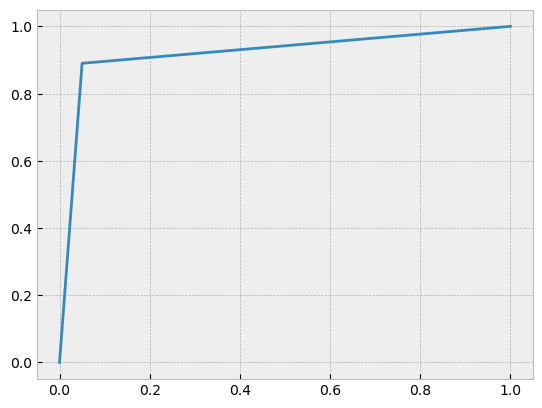

In [12]:
from sklearn.metrics import roc_curve, roc_auc_score

# Based on data only
fpr, tpr,_ = roc_curve(t-1, prediction-1)
plt.plot(fpr, tpr);

print('AUC = ', roc_auc_score(t-1,prediction-1))

## Exercise

1. Suppose you have a target detection task that you would like to evaluate using ROC curve analysis. You emplaced 10 targets and collected aerial hyperspectral imagery over 15 $km^2$. Then, suppose you ran a set of alarm generation and target detection algorithms over the collected data. Your algorithms produced the following list of alarm confidence values. You have already matched each of these alarms to a location on the ground and compared them with you ground truth. True targets, based on your ground truth, are marked with a "T" in the second column. Draw the associated ROC cure for these results.

|Alarm confidence values |  0.91  |  0.90  |  0.80  |  0.79  |  0.77  |  0.75  |  0.50  |  0.40  |  0.39  |  0.38  |  0.37  |  0.25  |  0.10  |  0.09  |  0.01  |
|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|--------|
|Ground truth |   T    |   T    |        |   T    |        |        |        |   T    |        |        |        |        |        |   T    |        |

2. Suppose you were segmenting a data set into three classes (e.g., vegetation, man-made materials, sand) and wanted to evaluate your results. Would using a ROC curve be an appropriate method for evaluation? Why or why not?

---

# Principal Component Analysis (PCA)

A very common approach (and one of the simplest approaches) to **dimensionality reduction** is **Principal Component Analysis** (or **PCA**). 

* PCA takes data from *sensor coordinates* to *data centric coordinates* using linear transformations.

PCA uses a **linear transformation** to **minimize the redundancy** of the resulting transformed data (by ending up with data that is uncorrelated).
* This means that every transformed dimension is more informative.
* In this approach, the dimensionality of the space is still the same as the original data, but the space of features are now arranged such that they contain the most information.

If we wish to reduce dimensionality of our feature space, we can choose only the features that carry over the most information in the linearly transformed space.
* In other words, PCA will find the underlying **linear manifold** that the data is embedded in.

**PCA finds the directions of maximum variance in high-dimensional data and projects it onto a new subspace with equal or fewer dimensions than the original one**. 

There are a couple of points-of-view on how to find $A$: 

1. Maximum Variance Formulation
2. Minimum-error Formulation

---